
## 1. Загрузка данных и первичный осмотр

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
df_allmusic = pd.read_csv('final_df1_cleaned.csv')
df_lastfm = pd.read_csv('lastfm_api_final.csv')

In [ ]:
df_allmusic.shape, df_lastfm.shape

((19895, 10), (19909, 8))

In [ ]:
df_allmusic.head(3)

,week_date,artist,album_title,label,genre,rating,release_date,duration,styles,release_year
0,2026-04-10,36 Crazyfists,Rest Inside the Flames,Music on Vinyl,Pop/Rock,8.0,2006-06-26,40.0,"Alternative Metal , Heavy Metal , Alternative/...",2006.0
1,2026-04-10,3TM,Lake,Ultra Vybe,Jazz,NaN,NaN,NaN,NaN,NaN
2,2026-04-10,A$AP Rocky,Don't Be Dumb,Columbia / RCA,Rap,7.0,2026-01-16,52.0,"Contemporary Rap , East Coast Rap , Cloud Rap ...",2026.0


In [ ]:
df_lastfm.head(3)

,Unnamed: 0,artist,album_title,listeners,playcount,artist_bio,top_tracks,top_albums
0,0,36 Crazyfists,Rest Inside the Flames,142201.0,3463219.0,36 Crazyfists was an alternative metal band fo...,"Bloodwork, At The End Of August, The Heart And...","A Snow Capped Romance, Bitterness the Star, Re..."
1,1,3TM,Lake,613.0,6562.0,3TM is a trio formation including Teppo Mäkyne...,"Five New Dukes, Laws Of Life, Flaigology, Seve...","Form, Lake, Abyss (A Prelude to Lake), Five Ne..."
2,2,A$AP Rocky,Don't Be Dumb,775666.0,20545054.0,"Rakim Athelston Mayers (born October 3, 1988),...","Sundress, Praise the Lord (Da Shine) (feat. Sk...","LONG.LIVE.A$AP (Deluxe Version), AT.LONG.LAST...."


In [ ]:
df_allmusic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19895 entries, 0 to 19894
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   week_date     19895 non-null  object 
 1   artist        19895 non-null  object 
 2   album_title   19895 non-null  object 
 3   label         19895 non-null  object 
 4   genre         19895 non-null  object 
 5   rating        2012 non-null   float64
 6   release_date  17202 non-null  object 
 7   duration      14089 non-null  float64
 8   styles        6880 non-null   object 
 9   release_year  17202 non-null  float64
dtypes: float64(3), object(7)
memory usage: 1.5+ MB


In [ ]:
df_lastfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19909 entries, 0 to 19908
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   19909 non-null  int64  
 1   artist       19909 non-null  object 
 2   album_title  19909 non-null  object 
 3   listeners    19909 non-null  float64
 4   playcount    19909 non-null  float64
 5   artist_bio   19909 non-null  object 
 6   top_tracks   19909 non-null  object 
 7   top_albums   19909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 1.2+ MB


## 2. Объединение датасетов (Join)

In [ ]:
df_allmusic['artist_key'] = df_allmusic['artist'].apply(lambda x: x.lower().strip())
df_allmusic['album_key'] = df_allmusic['album_title'].apply(lambda x: x.lower().strip())

df_lastfm['artist_key'] = df_lastfm['artist'].apply(lambda x: x.lower().strip())
df_lastfm['album_key'] = df_lastfm['album_title'].apply(lambda x: x.lower().strip())

In [ ]:
df = df_allmusic.merge(df_lastfm, on=['artist_key', 'album_key'], how='inner')

df = df.drop(columns=['artist_y', 'album_title_y', 'artist_key', 'album_key'])

df = df.rename(columns={'artist_x': 'artist', 'album_title_x': 'album_title'})

In [ ]:
df.sample(5)

,week_date,artist,album_title,label,genre,rating,release_date,duration,styles,release_year,Unnamed: 0,listeners,playcount,artist_bio,top_tracks,top_albums
3442,2026-03-06,Akira Kosemura,Bedroom Dance,Universal,Classical,NaN,2026-03-06,2.0,Classical Crossover,2026.0,3505,455.0,1273.0,Akira Kosemura (小瀬村晶) is a composer who lives ...,"Hicari, Inside River, Pt. 2, Minerva, Light Da...","In The Dark Woods, Polaroid Piano, Diary 2016-..."
16180,2025-12-12,Amarjeet Akela,Lev Lagawal Yadav Ji Ke Far Se,My Dhun Official,Pop/Rock,NaN,2025-12-10,3.0,NaN,2025.0,16379,0.0,0.0,"<a href=""https://www.last.fm/music/Amarjeet+A...","Kamar Dhake Mare Bhataar, Jaan De Diha Jahar M...","Kamar Dhake Mare Bhataar, Mujhe Yaad Karogi, K..."
3344,2026-03-13,WILD BLUE,You,Virgin,Pop/Rock,NaN,2026-03-11,3.0,"Asian Pop , J-Pop",2026.0,3407,156.0,770.0,There are two artists under this name:\n\n1. ...,"Bubbles, Fire With Fire, First Light, WILD BLU...","Bubbles, No More Jinx, POP, First Light, Wild ..."
6555,2026-02-13,Bic Runga,Red Sunset,Bic Runga,Pop/Rock,NaN,2026-02-13,29.0,"Adult Alternative Pop/Rock , Alternative Singe...",2026.0,6657,2311.0,14989.0,Briolette Kah Bic Runga (born 13 January 1976)...,"Sway, Get Some Sleep, Something Good, Drive, L...","Drive, Beautiful Collision, Birds, American Pi..."
13876,2026-01-09,Ari Vellora,Brillantes,Thunder Records,Rap,NaN,2026-01-07,3.0,NaN,2026.0,14041,0.0,0.0,"<a href=""https://www.last.fm/music/Ari+Vellor...","Lucia, Perdido, Copa de Cristal, Brisa, Adios","Lucia, Perdido, Copa de Cristal, Brisa, Adios"



## 3. EDA объединённого датасета:

### 3.2 Базовая статистика

In [ ]:
df[['rating', 'listeners', 'playcount', 'duration']].describe()

,rating,listeners,playcount,duration
count,2012.000000,1.989800e+04,1.989800e+04,14090.000000
mean,6.417495,1.309279e+04,2.812857e+05,13.506884
std,1.498765,8.989210e+04,3.826817e+06,17.357345
min,1.000000,0.000000e+00,0.000000e+00,0.000000
25%,5.000000,3.000000e+00,1.200000e+01,3.000000
50%,7.000000,3.250000e+01,1.490000e+02,4.000000
75%,7.000000,2.090000e+02,1.142750e+03,22.000000
max,9.000000,2.628806e+06,3.130442e+08,60.000000


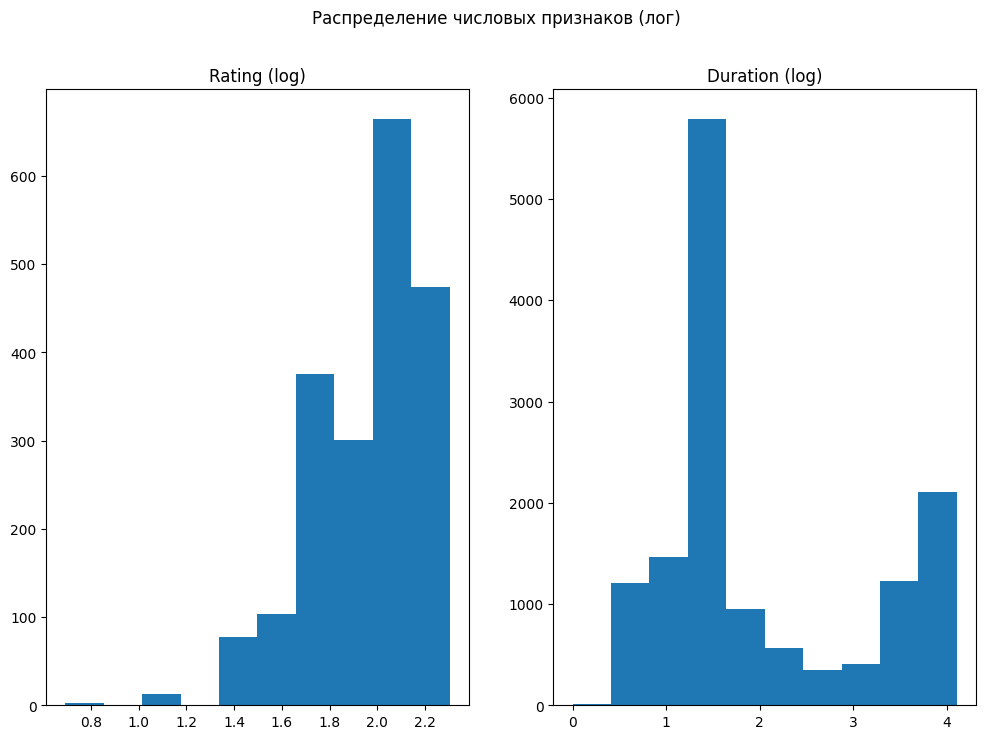

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.hist(np.log1p(df['rating'].dropna()))
plt.title('Rating (log)')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['duration'].dropna()))
plt.title('Duration (log)')

plt.suptitle('Распределение числовых признаков (лог)')

plt.show()

In [ ]:
df.describe()

,rating,duration,release_year,Unnamed: 0,listeners,playcount
count,2012.000000,14090.000000,17205.000000,19898.000000,1.989800e+04,1.989800e+04
mean,6.417495,13.506884,2023.835339,10077.747362,1.309279e+04,2.812857e+05
std,1.498765,17.357345,7.195684,5806.740511,8.989210e+04,3.826817e+06
min,1.000000,0.000000,1955.000000,0.000000,0.000000e+00,0.000000e+00
25%,5.000000,3.000000,2025.000000,5058.250000,3.000000e+00,1.200000e+01
50%,7.000000,4.000000,2026.000000,10075.500000,3.250000e+01,1.490000e+02
75%,7.000000,22.000000,2026.000000,15096.750000,2.090000e+02,1.142750e+03
max,9.000000,60.000000,2026.000000,20150.000000,2.628806e+06,3.130442e+08


### 3.3 Анализ жанров

In [ ]:
df['genre'].value_counts()

,count
genre,
Pop/Rock,8755
Electronic,1644
Rap,1529
Classical,1455
International,1184
Jazz,1175
Religious,797
Latin,740
R&B,580


In [ ]:
valid_genres = ['Pop/Rock', 'Electronic', 'Rap', 'Classical', 'International', 'Jazz','Religious', 'Latin', 'R&B', 'Stage & Screen', 'Folk', 'Country','Reggae', 'Blues', 'Easy Listening', 'Vocal', 'Avant-Garde',"Children's", 'Comedy/Spoken', 'New Age', 'Holiday']

df_genre = df[df['genre'].isin(valid_genres)].copy()

In [ ]:
genre_counts = df_genre['genre'].value_counts()

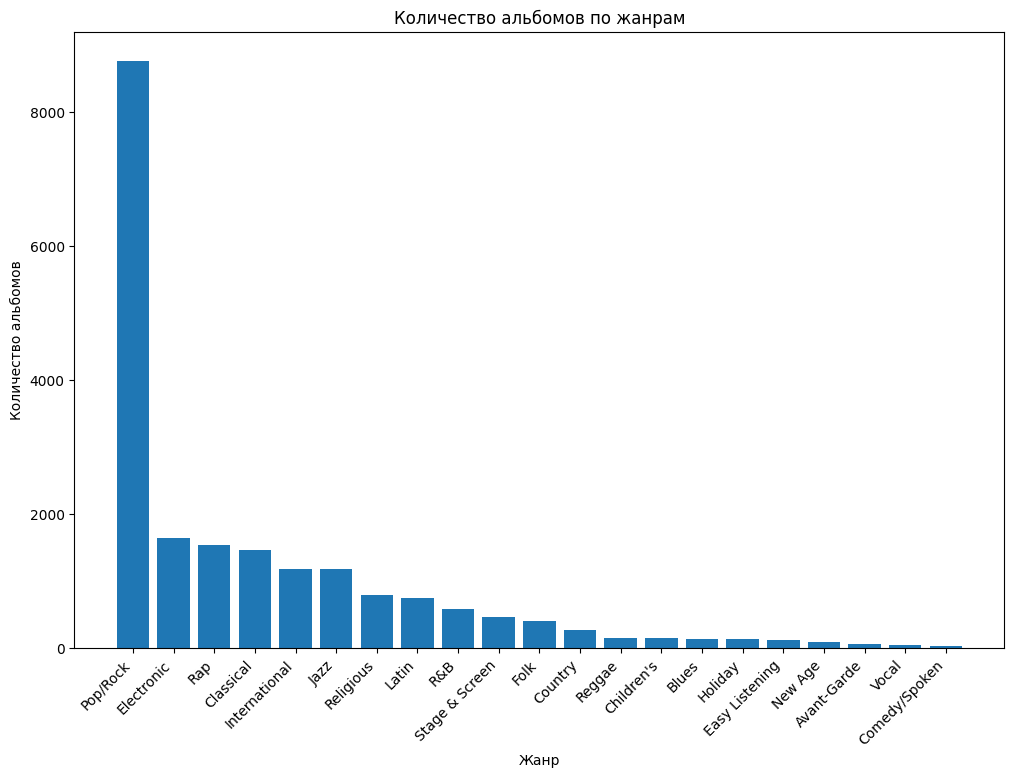

In [ ]:
plt.figure(figsize=(12, 8))
plt.bar(genre_counts.index, genre_counts.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Жанр')
plt.ylabel('Количество альбомов')
plt.title('Количество альбомов по жанрам')
plt.show()

In [ ]:
genre_summary = df.groupby('genre')[['rating', 'listeners', 'playcount', 'duration']].mean()

genre_summary = genre_summary.sort_values('listeners', ascending=False)

genre_summary

,rating,listeners,playcount,duration
genre,,,,
5,NaN,402295.000000,3.061049e+06,51.000000
8,NaN,256856.000000,5.805985e+06,1.000000
4,NaN,236868.000000,6.951147e+06,1.000000
6,NaN,98715.666667,1.575017e+06,46.500000
Vocal,6.607143,43776.932432,3.618026e+05,35.333333
7,NaN,42649.111111,7.183666e+05,37.714286
R&B,6.490196,32598.462069,3.470097e+05,13.226415
Pop/Rock,6.257630,21641.841519,4.753758e+05,13.818890
Blues,7.117647,13347.390152,1.266293e+05,22.640625


In [ ]:
rated = df_genre.dropna(subset=['rating'])

genre_rating = rated.groupby('genre')['rating'].mean().sort_values(ascending=False)

genre_rating

,rating
genre,
Children's,7.500000
Blues,7.117647
Avant-Garde,7.058824
Folk,6.791667
Jazz,6.763441
International,6.761905
Comedy/Spoken,6.750000
Reggae,6.727273
Vocal,6.607143


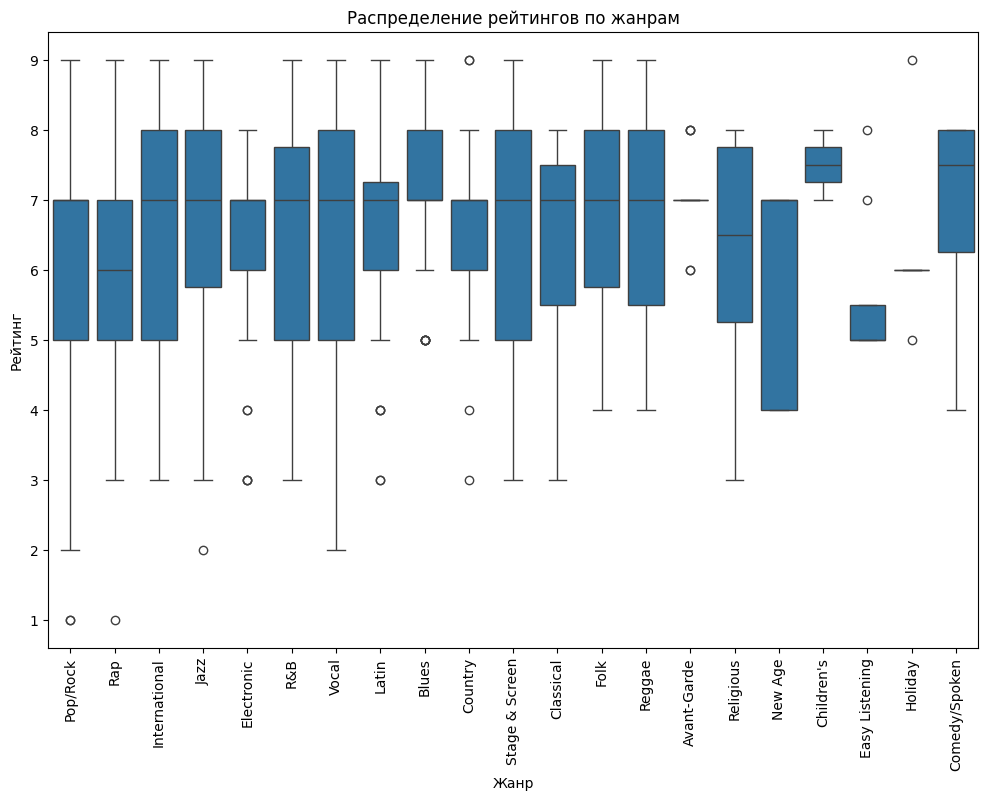

In [ ]:
plt.figure(figsize=(12, 8))

sns.boxplot(data=rated, x='genre', y='rating')

plt.xticks(rotation=90)
plt.xlabel('Жанр')
plt.ylabel('Рейтинг')
plt.title('Распределение рейтингов по жанрам')

plt.show()

### 3.4 Анализ популярности (Last.fm)

In [ ]:
pop = df_genre.copy()
genre_pop = pop.groupby('genre')['listeners'].mean()
genre_pop = genre_pop.sort_values(ascending=False)
genre_pop

,listeners
genre,
Vocal,43776.932432
R&B,32598.462069
Pop/Rock,21641.841519
Blues,13347.390152
Rap,11953.832243
Latin,10390.790541
Country,9339.703297
Holiday,7642.543651
Electronic,5282.224453


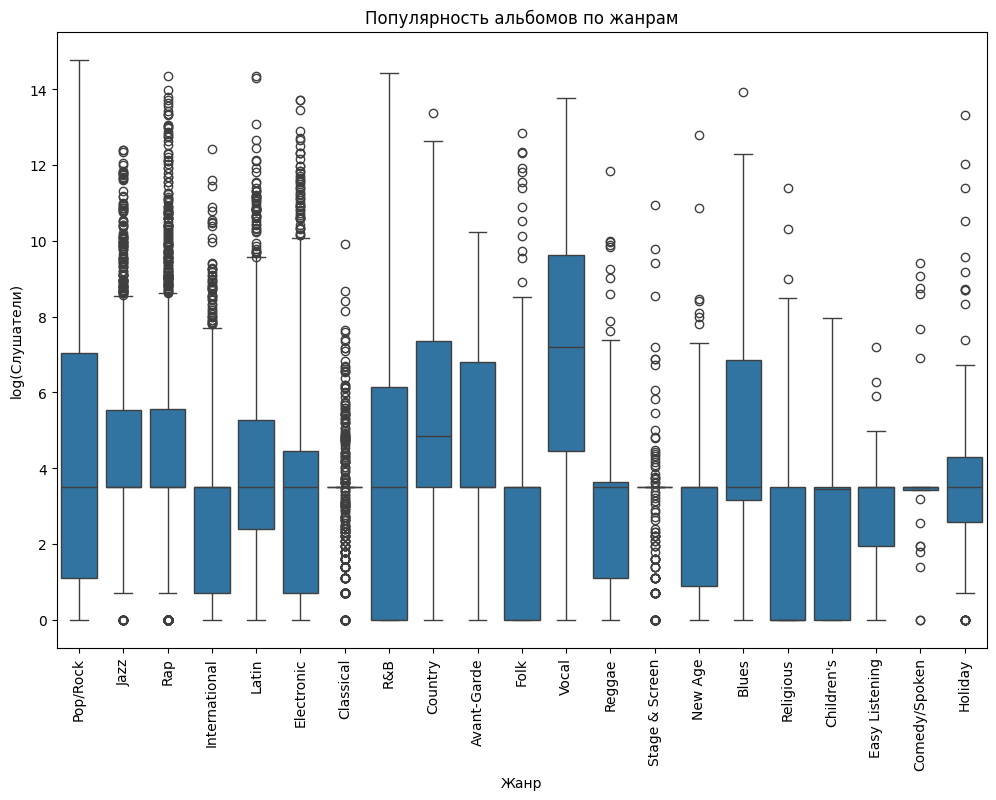

In [ ]:
pop['log_listeners'] = np.log1p(pop['listeners'])


plt.figure(figsize=(12, 8))

sns.boxplot(data=pop, x='genre', y='log_listeners')

plt.xticks(rotation=90)
plt.xlabel('Жанр')
plt.ylabel('log(Слушатели)')
plt.title('Популярность альбомов по жанрам')

plt.show()

In [ ]:
top_albums = df.sort_values('listeners', ascending=False)
top_albums = top_albums.head()
top_albums[['artist', 'album_title', 'genre', 'listeners', 'playcount', 'rating']]

,artist,album_title,genre,listeners,playcount,rating
18557,Panic! At the Disco,A Fever You Can't Sweat Out,Pop/Rock,2628806.0,108048845.0,3.0
19818,Two Door Cinema Club,Tourist History,Pop/Rock,2619285.0,70697067.0,6.0
11086,The Neighbourhood,Wiped Out!,Pop/Rock,2182147.0,80536118.0,5.0
10664,M83,"Hurry Up, We're Dreaming",Pop/Rock,2102800.0,50558029.0,9.0
8636,Kate Bush,Hounds of Love,Pop/Rock,2091429.0,38000075.0,9.0


In [ ]:
sc = df_genre[df_genre['listeners'] > 0]
corr = sc[['listeners', 'playcount']].corr()
corr

,listeners,playcount
listeners,1.000000,0.635438
playcount,0.635438,1.000000


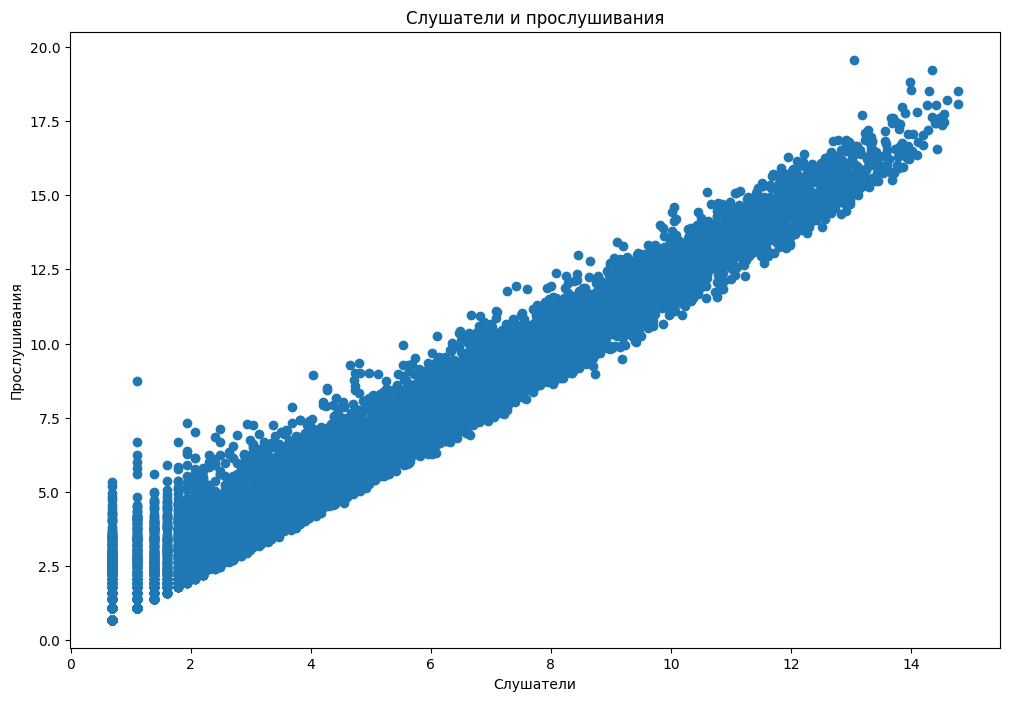

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(np.log1p(sc['listeners']), np.log1p(sc['playcount']))

plt.xlabel('Слушатели')
plt.ylabel('Прослушивания')
plt.title('Слушатели и прослушивания')

plt.show()

### 3.5 Анализ длительности

In [ ]:
dur = df_genre.dropna(subset=['duration'])
dur = dur[dur['duration'] > 0]
dur = dur[dur['duration'] <= 60]

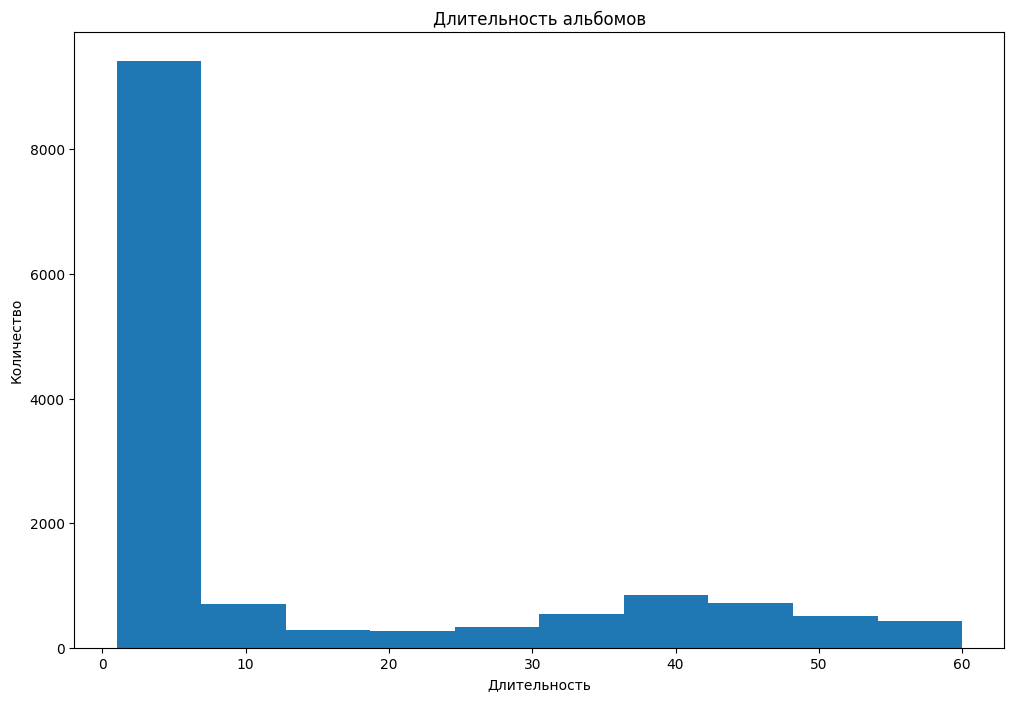

In [ ]:
plt.figure(figsize=(12, 8))
plt.hist(dur['duration'])
plt.xlabel('Длительность')
plt.ylabel('Количество')
plt.title('Длительность альбомов')

plt.show()

In [ ]:
genre_dur = dur.groupby('genre')['duration'].mean()
genre_dur = genre_dur.sort_values(ascending=False)
genre_dur

,duration
genre,
Comedy/Spoken,36.636364
Vocal,35.333333
Jazz,30.674074
Avant-Garde,27.545455
Blues,22.640625
Easy Listening,20.460784
Country,18.825581
Holiday,16.561905
Folk,15.626230


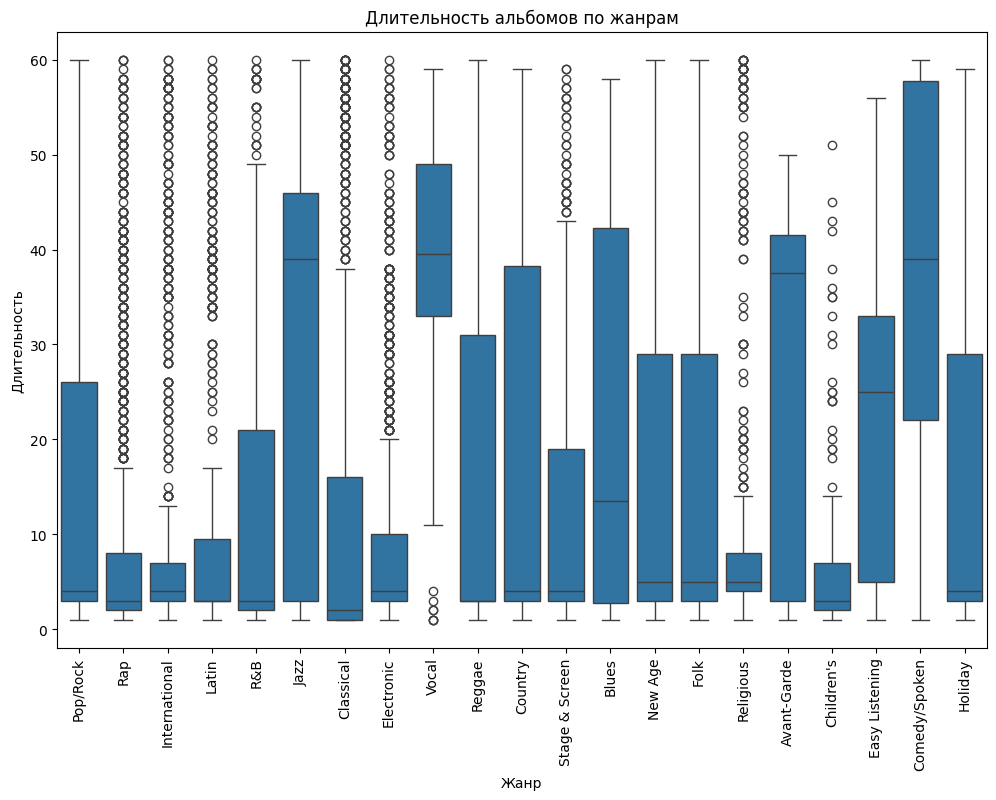

In [ ]:
plt.figure(figsize=(12, 8))

sns.boxplot(x='genre', y='duration', data=dur)

plt.xlabel('Жанр')
plt.ylabel('Длительность')
plt.xticks(rotation=90)
plt.title('Длительность альбомов по жанрам')

plt.show()

### 3.6 Анализ рейтинга

In [ ]:
rv = df.dropna(subset=['rating'])

corr = rv[['rating', 'listeners']].corr()

corr

,rating,listeners
rating,1.000000,0.091477
listeners,0.091477,1.000000


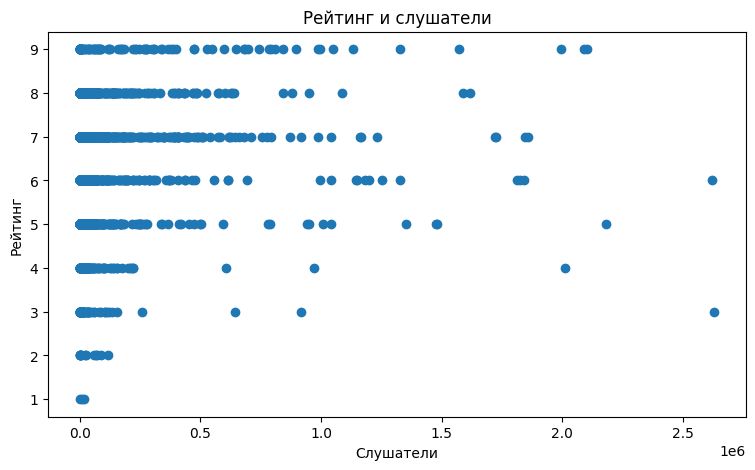

In [ ]:
plt.figure(figsize=(9, 5))

plt.scatter(rv['listeners'], rv['rating'])

plt.xlabel('Слушатели')
plt.ylabel('Рейтинг')
plt.title('Рейтинг и слушатели')

plt.show()

In [ ]:
ry = df.dropna(subset=['rating', 'release_year'])

ry = ry[ry['release_year'] >= 1950]
ry = ry[ry['release_year'] <= 2026]

ry['decade'] = (ry['release_year'] // 10) * 10

decade_rating = ry.groupby('decade')['rating'].mean()

decade_count = ry.groupby('decade')['rating'].count()

decade_rating = decade_rating[decade_count >= 5]

decade_rating

,rating
decade,
1950.0,7.000000
1960.0,7.142857
1970.0,7.207547
1980.0,6.583333
1990.0,5.944206
2000.0,6.086093
2010.0,6.329609
2020.0,6.755396


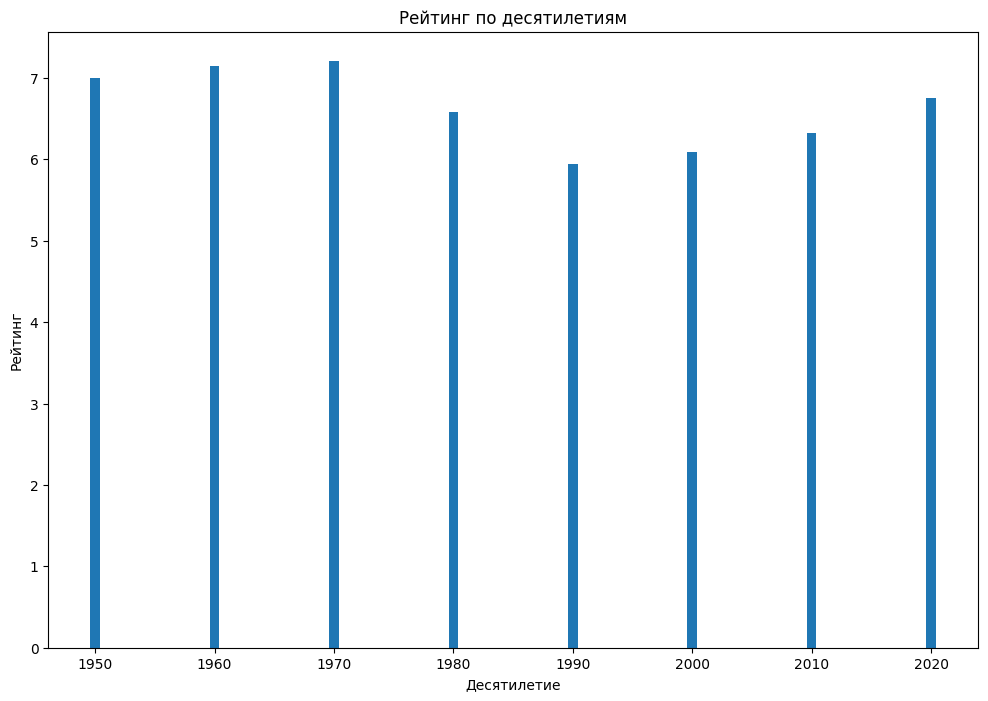

In [ ]:
plt.figure(figsize=(12, 8))

plt.bar(decade_rating.index, decade_rating.values)

plt.xlabel('Десятилетие')
plt.ylabel('Рейтинг')
plt.title('Рейтинг по десятилетиям')

plt.show()

### 3.7 Матрица корреляций

In [ ]:
corr_df = df[['rating', 'listeners', 'playcount', 'duration', 'release_year']]

corr_df

,rating,listeners,playcount,duration,release_year
0,8.0,142201.0,3463219.0,40.0,2006.0
1,NaN,613.0,6562.0,NaN,NaN
2,7.0,775666.0,20545054.0,52.0,2026.0
3,NaN,32.5,149.0,4.0,2026.0
4,NaN,32.5,149.0,NaN,2026.0
...,...,...,...,...,...
19893,NaN,5.0,30.0,3.0,2025.0
19894,5.0,32.5,149.0,NaN,1964.0
19895,NaN,6453.0,55731.0,34.0,2025.0
19896,NaN,0.0,0.0,4.0,2025.0


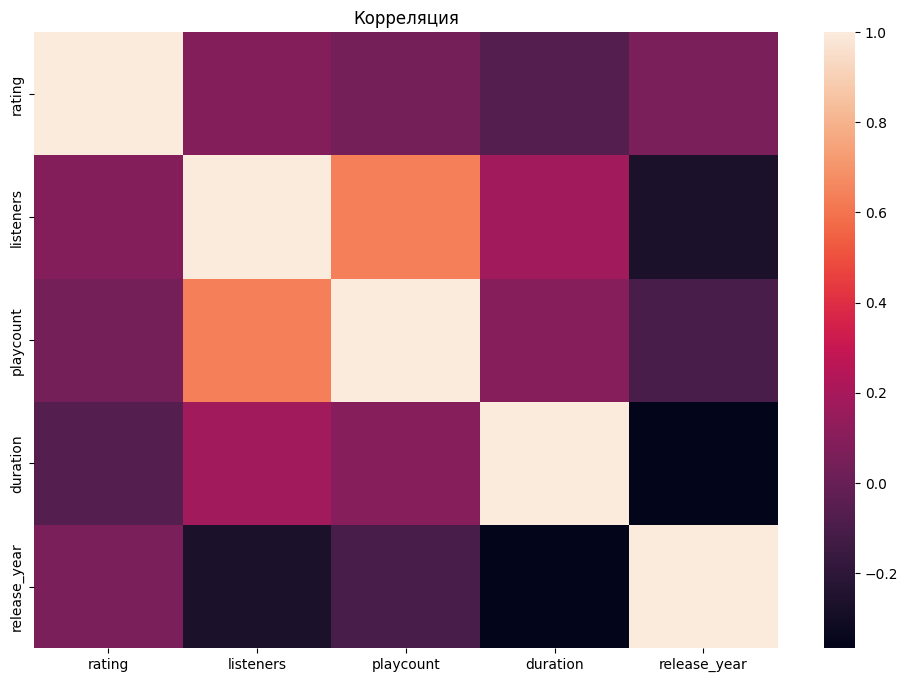

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(corr_df.corr(), annot=True)

plt.title('Корреляция')

plt.show()

### 3.8 Вовлечённость аудитории

In [ ]:
eng = df_genre[df_genre['listeners'] > 100].copy()

eng['engagement'] = eng['playcount'] / eng['listeners']
eng['log_engagement'] = np.log1p(eng['engagement'])

eng_mean = eng.groupby('genre')['engagement'].mean()
eng_count = eng.groupby('genre')['engagement'].count()

top_eng = eng_count[eng_count >= 20].index

plot_eng = eng[eng['genre'].isin(top_eng)]

order_e = plot_eng.groupby('genre')['engagement'].mean().sort_values(ascending=False).index

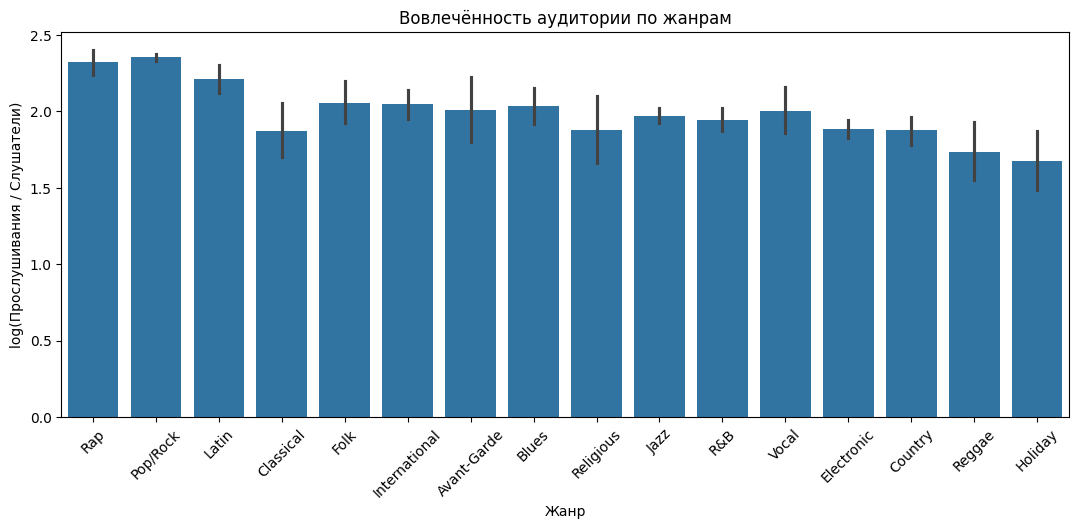

In [ ]:
plt.figure(figsize=(13, 5))
sns.barplot(data=plot_eng, x='genre', y='log_engagement', order=order_e)
plt.xticks(rotation=45)
plt.xlabel('Жанр')
plt.ylabel('log(Прослушивания / Слушатели)')
plt.title('Вовлечённость аудитории по жанрам')
plt.show()